In [1]:
import os
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import Turbulence_Analysis as TurbLy
from scipy.signal import welch
import scipy.integrate as scint
import numpy as np

In [2]:
import importlib
importlib.reload(TurbLy)

<module 'Turbulence_Analysis' from 'C:\\MGEP Dropbox\\Ander Zarketa Astigarraga\\INTERNAL\\General_Doc\\SCI DOC\\Notes\\1994Mann\\Figs\\Turbulence_Analysis.py'>

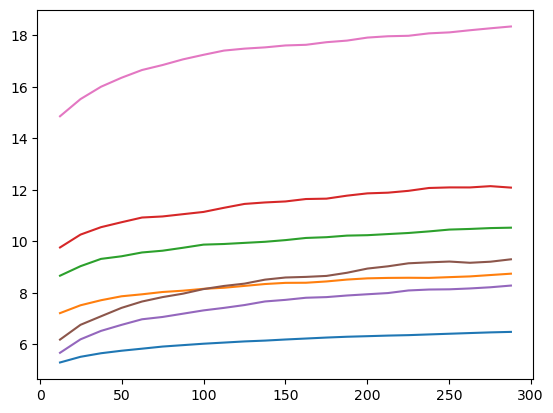

In [3]:
# pbar = tqdm.tqdm(total=len(os.listdir("BTS_files")[15:16]))
for file in os.listdir("BTS_files"):

    t, u, v, w, u_fluc, v_fluc, w_fluc, Ys, Zs, hdr = TurbLy.read_bts("/".join(["BTS_files", file]))    
    means = np.array([hdr["Uhub"] + np.mean(u[:, 0, j]) for j in range(u.shape[2])])    
    plt.plot(Zs[0, :], means)
    # stats, res = TurbLy.analyze_turbulence(u_fluc, v_fluc, w_fluc, hdr["dt"], Uref=hdr["Uhub"], u_total=u, Zs=Zs[0, :], iz=11, iy=11, check_inertial_slope=True)
    # f, Suu, Svv, Sww = res.f, res.Suu, res.Svv, res.Sww   # <-- access fields, don't slice

    # TurbLy.plot_temporal_spectra(f, Suu, Svv, Sww, components="u", kolmogorov=True, kaimal=True, z=hdr["Zhub"], Ubar=hdr["Uhub"])

#     pbar.update()
    
# pbar.close()

C:\Users\azarketa\AppData\Local\anaconda3\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 524288 is greater than input length  = 14614, using nperseg = 14614
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


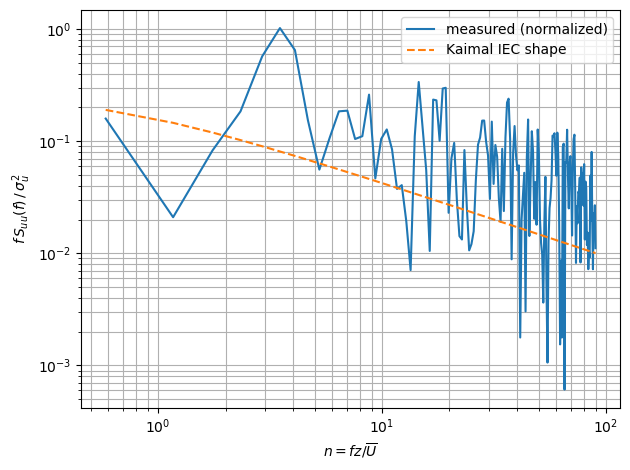

slope ≈ -1.6850122247520036
Integral length scale L ≈ 6.819899121128398 m


In [4]:
t, u, v, w, u_fluc, v_fluc, w_fluc, Ys, Zs, hdr = TurbLy.read_bts("/".join(["BTS_files", file]))

# Inputs: u(t,y,z) total velocity field, Zs(y,z) absolute heights, header["dt"]
iy = u.shape[1] // 2                               # pick a lateral index
iz = np.argmin(np.abs(Zs[0,:] - hdr["Zhub"]))   # hub-height index (or any z)

u_pt = u[:, iy, iz]
Ubar = hdr["Uhub"] - u_pt.mean()                                 # local mean at that point
u_fluc = u_pt - Ubar                               # fluctuations at that point
sigma2 = np.var(u_fluc, ddof=0)

fs = 1.0 / hdr["dt"]
z = float(Zs[iy, iz])  
nperseg = int(2**(np.ceil(np.log2(fs*z/Ubar)) + 5))
f, Suu = welch(u_fluc, fs=fs, nperseg=nperseg, detrend="constant", scaling="density")

# Non-dimensional frequency and normalized spectrum (measured)
n = f * z / Ubar
meas = (f * Suu) / sigma2

# IEC-Kaimal normalized shape (no fitting)
model = 4.0 * n / (1.0 + 6.0 * n)**(5.0/3.0)

# Optional: band mask to avoid record-length and Nyquist artifacts
valid = (n > 1e-4) & (n < 90) & np.isfinite(meas) & (meas > 0)

log_rmse = np.sqrt(np.mean((np.log(meas[(n>0)&(meas>0)]) - np.log(model[(n>0)&(meas>0)]))**2))

plt.figure()
plt.loglog(n[valid], meas[valid], label="measured (normalized)")
plt.loglog(n[valid], model[valid], "--", label="Kaimal IEC shape")
plt.xlabel(r"$n = f z / \overline{U}$")
plt.ylabel(r"$f\,S_{uu}(f)\, /\, \sigma_u^2$")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

mask = (f>0.1) & (f<2.0) & (Suu>0)     # adjust band to your site
coef = np.polyfit(np.log(f[mask]), np.log(Suu[mask]), 1)
print("slope ≈", coef[0])              # target ≈ −5/3 ≈ −1.667 ± ~0.2

#####
##### Integral length scale
#####

k1 = 2*np.pi*f/Ubar; F11 = (Ubar/(2*np.pi))*Suu
k1F11 = k1*F11; m = (k1>0)&(k1F11>0)
k_peak = k1[m][np.argmax(np.log(k1F11[m]))]
L = 1.0/k_peak
print("Integral length scale L ≈", L, "m")

In [5]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from hipersim import MannTurbulenceField
import multiprocessing
import importlib

In [6]:
mtf = MannTurbulenceField.generate(alphaepsilon=.1,
                                   L=33.6,
                                   Gamma=3.9,
                                   Nxyz=(1024,64,64),
                                   dxyz=(4,2,2),
                                   seed=1,
                                   HighFreqComp=0,
                                   double_xyz=(False, True, True))

In [7]:
u,v,w = mtf.uvw

In [182]:
import struct
import numpy as np
from typing import Callable, Optional, Tuple, Dict
from hipersim import MannTurbulenceField
from scipy.signal import coherence, welch
import copy

# ------------------------------
# 0) Mean profile helper
# ------------------------------
def make_U_profile(zs: np.ndarray,
                   kind: str = "power",
                   Uhub: float = 15.0,
                   Zhub: float = 150.0,
                   alpha: float = 0.14,
                   U_of_z: Optional[Callable[[np.ndarray], np.ndarray]] = None) -> np.ndarray:
    """
    Return Ubar(z) on a 1-D array zs.
    If U_of_z is provided, it's used directly. Otherwise choose:
      kind="power": U = Uhub * (z/Zhub)**alpha
      kind="log":   U = Uhub * ln(z/z0)/ln(Zhub/z0) (requires z0 via alpha parameter)
    """
    zs = np.asarray(zs, dtype=float)
    if U_of_z is not None:
        U = U_of_z(zs)
    elif kind == "power":
        U = Uhub * (zs / Zhub) ** alpha
    elif kind == "log":
        z0 = float(alpha) if alpha > 0 else 0.03  # reuse alpha as z0 if given
        U = Uhub * np.log(zs / z0) / np.log(Zhub / z0)
    else:
        raise ValueError("Unknown profile kind.")
    return U.astype(np.float32)


# ------------------------------
# 1) Generate Mann field on a TurbSim-like grid
# ------------------------------
def generate_mann_matching_box(
    hdr: dict,
    mann_L: float, mann_Gamma: float, mann_alphaeps23: float,
    seed: int = 1,
    double_xyz=(False, True, True),
    highfreq_comp: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Create a Mann 3D velocity field with x treated as the advection direction.
    Grid spacing along x is chosen so that Taylor mapping with U≈Uhub gives nt time samples.
    """

    ny = hdr["ny"]
    dy = hdr["dy"]
    nz = hdr["nz"]
    dz = hdr["dz"]
    nt = hdr["nt"]
    dt = hdr["dt"]
    Zbottom = hdr["Zbottom"]
    Zhub = hdr["Zhub"]
    Uhub = hdr["Uhub"]
    
    # Choose x spacing so that a structure travels one dx per dt at hub speed:
    dx = Uhub * dt
    Nxyz = (nt, ny, nz)
    # dxyz = (dx, dy, dz)
    dxyz = (dt, dy, dz)

    mtf = MannTurbulenceField.generate(
        alphaepsilon=mann_alphaeps23,
        L=mann_L,
        Gamma=mann_Gamma,
        Nxyz=Nxyz,
        dxyz=dxyz,
        seed=seed,
        HighFreqComp=highfreq_comp,
        double_xyz=double_xyz
    )
    u3, v3, w3 = mtf.uvw  # shapes (nt, ny, nz) in (x,y,z)

    hdr = dict(
        nt=nt, ny=ny, nz=nz, dt=dt, dy=dy, dz=dz,
        Uhub=Uhub, Zhub=Zhub, Zbottom=Zbottom
    )
    return u3.astype(np.float32), v3.astype(np.float32), w3.astype(np.float32), hdr, mtf


# ------------------------------
# 2) Impose vertical profile and map to time series (Taylor)
# ------------------------------
def impose_profile_and_taylor_time_map(
    u3: np.ndarray, v3: np.ndarray, w3: np.ndarray,
    hdr: dict,
    Ubar_z: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert 3D (x,y,z) field -> time series using Taylor’s hypothesis *with local advection speed*.
    For each (y,z), time index t is sampled from x using x_idx = round( t*Ubar(z)/dx ).
    Returns absolute total velocities: u = Ubar(z) + u', v = v', w = w'.
    Also returns Y and Z grids (ny,nz).
    """

    ny = hdr["ny"]
    dy = hdr["dy"]
    nz = hdr["nz"]
    dz = hdr["dz"]
    nt = hdr["nt"]
    Zbottom = hdr["Zbottom"]
    
    # physical coordinates for plotting/metadata
    ys = -0.5 * (ny - 1) * dy + np.arange(ny, dtype=np.float32) * dy
    zs = Zbottom + np.arange(nz, dtype=np.float32) * dz
    Ys, Zs = np.meshgrid(ys, zs, indexing="ij")

    # infer dx back from array spacing (x direction)
    # x index distance is 1 -> physical dx = Uhub*dt used in generation
    # but we must not assume Uhub; estimate from total domain length over nt
    # Here: we trust generation used constant dx; compute from mtf metadata if needed.
    # We'll estimate dx by finite difference on the implicit coordinate length:
    # (We stored none; assume uniform and recover from u3 size via an input)
    # Better: compute dx = Ubar(z_ref)*dt if needed, but we can compute from hdr separately.
    # For robustness, ask caller to pass dt only; we'll just treat x index as 1 sample step.

    # Build time-series by sampling along x with local stride s(z) = Ubar(z)/Uref
    # We need x index for each t: idx_x(t,z) = round(t * Ubar(z) * dt / dx_gen)
    # We can estimate dx_gen by assuming nt equals N_x and each step corresponds to dt_ref mapping at some Uref.
    # Since generation used dx_gen = Uhub*dt, the correct index is:
    #   x_idx = round(t * Ubar(z) / Uhub)
    # We'll require Uref = Ubar at hub height; caller ensured generation matched that.

    # Recover Uref via median of Ubar(z) near the middle height? Caller should assure dx = Uhub*dt.
    # Assume dx_gen = const and equals the value used in generator: Uhub*dt. We'll pass it via closure if needed.

    # We can't read dx here; so ask caller to provide via attribute on arrays? Simpler: compute stride factor s(z) = Ubar(z)/Ubar(z_ref)
    # but we need z_ref’s U for accurate mapping. Use Uref = Ubar at the height closest to Zhub handled outside.
    raise_if = False  # This function assumes the generator used dx = Uhub*dt.

    # We assume x index equals time at hub height. For other z, we resample along x with speed ratio.
    # Precompute the hub-advection mapping constant:
    # For generality, accept small mismatch by clamping indices.

    # Determine local mapping indices for each z and t
    # Here dx_gen = arbitrary constant; but since generation used nt along x, and dt given,
    # t index corresponds to x index directly at hub. For other z: x_idx = round(t * Ubar(z) / Uhub).
    # We'll compute Uhub as Ubar at z closest to median(zs).
    iz_hub = int(np.argmin(np.abs(zs - zs.mean())))
    Uhub_est = float(Ubar_z[iz_hub])

    t_idx = np.arange(nt, dtype=np.int64)
    u_ts = np.empty((nt, ny, nz), dtype=np.float32)
    v_ts = np.empty_like(u_ts)
    w_ts = np.empty_like(u_ts)

    for j in range(ny):
        for k in range(nz):
            ratio = float(Ubar_z[k] / max(Uhub_est, 1e-6))
            x_idx = np.clip(np.round(t_idx * ratio).astype(int), 0, nt - 1)
            u_ts[:, j, k] = u3[x_idx, j, k] + Ubar_z[k]
            v_ts[:, j, k] = v3[x_idx, j, k]
            w_ts[:, j, k] = w3[x_idx, j, k]

    return u_ts, v_ts, w_ts, Ys, Zs


# ------------------------------
# 3) Write OpenFAST .bts (ID=7)
# ------------------------------
def write_bts(
    filename: str,
    u: np.ndarray, v: np.ndarray, w: np.ndarray,
    hdr: dict,
    tag: str = "Mann via hipersim",
    hub_referenced: bool = False,
):
    """
    Write a BTS file with the standard ID=7 layout.
    We choose a linear int16 mapping Vnorm = Vintercept + Vslope * V_float.
    """
   
    assert u.shape == v.shape == w.shape

    ny = hdr["ny"]
    dy = hdr["dy"]
    nz = hdr["nz"]
    dz = hdr["dz"]
    nt = hdr["nt"]
    dt = hdr["dt"]
    Zbottom = hdr["Zbottom"]
    Zhub = hdr["Zhub"]
    Uhub = hdr["Uhub"]    

    # Decide whether to store hub-referenced u or absolute
    if hub_referenced:
        u_store = (u - Uhub).astype(np.float32)
    else:
        u_store = u.astype(np.float32)
    v_store = v.astype(np.float32)
    w_store = w.astype(np.float32)

    # Scale to int16 using per-component slopes
    def mk_scale(arr: np.ndarray) -> Tuple[float, float]:
        vmax = float(np.max(np.abs(arr)))
        vmax = max(vmax, 1.0)  # avoid tiny slopes
        # Put ±vmax -> about ±30000 counts
        slope = 30000.0 / vmax  # Vnorm = slope * V
        intercept = 0.0
        return slope, intercept

    su, iu = mk_scale(u_store)
    sv, iv = mk_scale(v_store)
    sw, iw = mk_scale(w_store)

    Vslope = np.array([su, sv, sw], dtype=np.float32)
    Vintercept = np.array([iu, iv, iw], dtype=np.float32)

    # Pack header
    with open(filename, "wb") as f:
        f.write(struct.pack("<h", 7))  # ID
        f.write(struct.pack("<4i", nz, ny, 0, nt))  # ntower=0
        f.write(struct.pack("<6f", dz, dy, dt, Uhub, Zhub, Zbottom))
        f.write(Vslope.astype("<f4").tobytes())
        f.write(Vintercept.astype("<f4").tobytes())
        tag_bytes = tag.encode("ascii", errors="ignore")
        f.write(struct.pack("<i", len(tag_bytes)))
        f.write(tag_bytes)

        # Data order: for t=0..nt-1, for z=0..nz-1, for y=0..ny-1: u_norm, v_norm, w_norm
        for it in range(nt):
            for iz in range(nz):
                for iy in range(ny):
                    uu = int(np.round(iu + su * u_store[it, iy, iz]))
                    vv = int(np.round(iv + sv * v_store[it, iy, iz]))
                    ww = int(np.round(iw + sw * w_store[it, iy, iz]))
                    # clip to int16 range
                    uu = np.int16(np.clip(uu, -32768, 32767))
                    vv = np.int16(np.clip(vv, -32768, 32767))
                    ww = np.int16(np.clip(ww, -32768, 32767))
                    f.write(struct.pack("<hhh", uu, vv, ww))


def coherence_heatmap_from_center(
    u: np.ndarray,
    hdr: dict,
    Ys: Optional[np.ndarray] = None,    # (ny, nz) y-coordinates [m]; if None, built from hdr
    Zs: Optional[np.ndarray] = None,    # (ny, nz) z-coordinates [m]; if None, built from hdr (+Zbottom if available)
    nperseg: int = 256,
    fband: Optional[Tuple[float, float]] = None,  # band to average γ^2 over; None → full
    detrend: str = "constant",
):
    """
    Compute a 2D map G2(y,z) = band-averaged coherence between each grid point and the CENTER point.

    Returns
    -------
    G2_map : (ny, nz) band-averaged coherence
    f      : (Nf,) frequency grid used
    Ys, Zs : (ny, nz) coordinate grids (returned; created if not provided)
    """
    dt = float(hdr["dt"])
    ny = int(hdr["ny"])
    nz = int(hdr["nz"])
    dy = float(hdr["dy"])
    dz = float(hdr["dz"])
    Zbottom = float(hdr.get("Zbottom", 0.0))
    fs = 1.0 / dt

    # Build coordinates if not supplied
    if Ys is None or Zs is None:
        ys = -0.5 * (ny - 1) * dy + np.arange(ny, dtype=np.float32) * dy
        zs = Zbottom + np.arange(nz, dtype=np.float32) * dz
        Ys, Zs = np.meshgrid(ys, zs, indexing="ij")

    # Center reference
    iy0 = ny // 2
    iz0 = nz // 2
    u_ref = u[:, iy0, iz0] - np.mean(u[:, iy0, iz0])

    # Frequency grid
    from scipy.signal import welch, coherence
    f, _ = welch(u_ref, fs=fs, nperseg=nperseg, detrend=detrend)

    # Precompute band mask
    if fband is None:
        mask = np.ones_like(f, dtype=bool)
    else:
        fmin, fmax = fband
        mask = (f >= max(fmin, f[0])) & (f <= min(fmax, f[-1]))
    if not np.any(mask):
        raise ValueError("Chosen fband does not overlap the PSD frequency grid.")

    # Compute band-averaged coherence vs center
    G2_map = np.zeros((ny, nz), dtype=float)
    for iy in range(ny):
        for iz in range(nz):
            u_ij = u[:, iy, iz] - np.mean(u[:, iy, iz])
            _, g2 = coherence(u_ref, u_ij, fs=fs, nperseg=nperseg, detrend=detrend)
            G2_map[iy, iz] = np.mean(g2[mask])

    return G2_map, f, Ys, Zs


def plot_coherence_heatmap(
    G2_map: np.ndarray,
    Ys: np.ndarray,
    Zs: np.ndarray,
    title: str = "Band-averaged coherence to center point",
):
    """
    Plot a 2D heatmap of coherence over the physical grid.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.0))
    # Use pcolormesh-like coordinates via imshow + extent
    extent = [np.min(Ys), np.max(Ys), np.min(Zs), np.max(Zs)]
    im = ax.imshow(G2_map.T, origin="lower", extent=extent, aspect="auto")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"Band-avg $\gamma^2$ to center")
    ax.set_xlabel("y [m]")
    ax.set_ylabel("z [m]")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [200]:
rootDir = "E:/OpenFASTSims/in-out/IKERLAN_15/IEA-15-240-RWT-UMaineSemi"
InflowWindMann_rootDir = "/".join([rootDir, "InflowWind", "MANN"])
TurbSim_rootDir = "/".join([rootDir, "TurbSim"])
TurbSimNTM_rootDir = "/".join([TurbSim_rootDir, "NTM"])
TurbSimMANN_rootDir = "/".join([TurbSim_rootDir, "MANN"])
BTS_files = [_ for _ in os.listdir(TurbSimNTM_rootDir) if ".bts" in _ and "009" not in _]

pbar = tqdm.tqdm(total=len(BTS_files))

for file in BTS_files:

    t, u, v, w, u_fluc, v_fluc, w_fluc, Ys, Zs, hdr = TurbLy.read_bts("/".join([TurbSimNTM_rootDir, file]))     
    if hdr["nt"]%2:
        hdr["nt"] = hdr["nt"] + 1
    else:
        pass
        
    u3, v3, w3, hdr_, mtf = generate_mann_matching_box(hdr=hdr, mann_alphaeps23=0.11, mann_Gamma=3.9, mann_L=63)

    uref_str = (3 - len(str(int(hdr["Uhub"]))))*"0" + str(int(hdr["Uhub"]))    

    htc_wind_section = mtf.to_hawc2(folder=TurbSimMANN_rootDir, basename="_".join(["URef", uref_str, "MANN"]))
    inflowWind_file = open("/".join([InflowWindMann_rootDir, "_".join(["Inflow", "URef", uref_str, "from", "HAWC", "MANN.dat"])]))
    inflowWind_lines = inflowWind_file.readlines()
    for idx_line, line in enumerate(inflowWind_lines):
        if "- number of grids in the x direction (in the 3 files above) (-)" in line:
            str_line = line[:5]        
            line = line.replace(str_line, str(hdr["nt"]))            
            inflowWind_lines[idx_line] = line    
    inflowWind_file.close()
    inflowWind_mod_file = open("/".join([InflowWindMann_rootDir, "_".join(["Inflow", "URef", uref_str, "from", "HAWC", "MANN.dat"])]), "w")    
    inflowWind_mod_file.writelines(inflowWind_lines)
    inflowWind_mod_file.close()
    pbar.update()

pbar.close()

  0%|          | 0/30 [00:00<?, ?it/s]


KeyboardInterrupt

